In [13]:
#Loading Data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

ecommerce_df = pd.read_csv('../Data/global_ecommerce_sales.csv')
ecommerce_df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [14]:
#Dataset Structure

ecommerce_df.head()
ecommerce_df.info()
ecommerce_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   str    
 1   Order_Date        2000 non-null   str    
 2   Customer_Name     2000 non-null   str    
 3   Customer_Segment  2000 non-null   str    
 4   Country           2000 non-null   str    
 5   Region            2000 non-null   str    
 6   Product_Category  2000 non-null   str    
 7   Product_Name      2000 non-null   str    
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   str    
dtypes: float64(4), int64(2), str(9)
memory usage: 234.5 KB


(2000, 15)

In [15]:
# Explore Individual Columns

ecommerce_df['Product_Category'].value_counts()
ecommerce_df['Total_Sales'].describe()

count    2000.000000
mean      242.279670
std       382.583802
min         2.420000
25%        41.227500
50%       113.125000
75%       266.552500
max      3813.980000
Name: Total_Sales, dtype: float64

In [16]:


ecommerce_df.loc[
    ecommerce_df['Total_Sales'] < 500,
    ['Country', 'Total_Sales', 'Product_Category']
]

,Country,Total_Sales,Product_Category
0,United States,298.29,Technology
1,Spain,313.38,Technology
2,Mexico,21.48,Office Supplies
3,Italy,105.16,Technology
5,Mexico,55.74,Furniture
...,...,...,...
1993,Australia,13.57,Office Supplies
1994,India,160.11,Furniture
1997,Spain,162.13,Technology
1998,Spain,45.12,Clothing & Accessories


In [17]:
df = (ecommerce_df['Total_Sales'] > 100) & (ecommerce_df["Country"] == "Italy").head(10)

ecommerce_df.loc[df].iloc[:, 0:5]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy


In [18]:
ecommerce_df.sort_values(by='Customer_Name', ascending=True).head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
1291,ORD-11384,2024-12-13,Ahmed Ali,Consumer,Mexico,North America,Clothing & Accessories,Cotton Formal Shirt,12,44.66,5,509.12,14.12,227.04,Credit Card
1064,ORD-10629,2024-08-25,Ahmed Anderson,Home Office,China,Asia Pacific,Technology,Smart LED Desk Lamp,4,33.42,0,133.68,13.19,46.97,PayPal
47,ORD-10787,2023-02-01,Ahmed Clark,Consumer,Canada,North America,Technology,Tablet Stand Holder,3,19.94,0,59.82,8.61,18.31,Bank Transfer
806,ORD-10064,2024-04-05,Ahmed Clark,Corporate,Japan,Asia Pacific,Clothing & Accessories,Cotton Formal Shirt,1,43.07,20,34.46,10.50,2.43,Bank Transfer
1958,ORD-10888,2025-12-09,Ahmed Dubois,Consumer,Spain,Europe,Technology,Tablet Stand Holder,1,45.07,5,42.82,9.42,8.61,Cash on Delivery


#cleaning and wrangling


In [19]:
ecommerce_df.rename(columns={
    "Total_Sales": "Sales"
}, inplace=True)
ecommerce_df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [20]:


ecommerce_df["Order_Date"] = pd.to_datetime(ecommerce_df["Order_Date"])
ecommerce_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   str           
 1   Order_Date        2000 non-null   datetime64[us]
 2   Customer_Name     2000 non-null   str           
 3   Customer_Segment  2000 non-null   str           
 4   Country           2000 non-null   str           
 5   Region            2000 non-null   str           
 6   Product_Category  2000 non-null   str           
 7   Product_Name      2000 non-null   str           
 8   Quantity          2000 non-null   int64         
 9   Unit_Price        2000 non-null   float64       
 10  Discount_Percent  2000 non-null   int64         
 11  Sales             2000 non-null   float64       
 12  Shipping_Cost     2000 non-null   float64       
 13  Profit            2000 non-null   float64       
 14  Payment_Method    2000 non-null   s

In [21]:
ecommerce_df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Sales               0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

In [22]:
ecommerce_df.duplicated()
ecommerce_df[ecommerce_df.duplicated()]

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Sales,Shipping_Cost,Profit,Payment_Method


In [23]:
ecommerce_df.head()
ecommerce_df["Country"].unique()
ecommerce_df["Payment_Method"].unique()
ecommerce_df["Product_Category"].value_counts()
ecommerce_df["Customer_Segment"].unique()
ecommerce_df["Order_Date"].dtype


dtype('<M8[us]')

Exploratory Data Analysis (EDA)

In [24]:
# Total Sales by Category
sales_by_category = ecommerce_df.groupby("Product_Category")["Sales"].sum()
print(f"Total sales by category: \n  {sales_by_category}")
region_sales = ecommerce_df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(f"Total sales by region: \n  {region_sales}")
category_profit = ecommerce_df.groupby("Product_Category")["Profit"].sum().sort_values()
print(f"Total profit by category: \n  {category_profit}")

Total sales by category: 
  Product_Category
Clothing & Accessories     69375.63
Furniture                 256274.68
Office Supplies            19390.81
Technology                139518.22
Name: Sales, dtype: float64
Total sales by region: 
  Region
Europe                  137006.20
North America           133876.38
Asia Pacific            121707.51
South America            46051.13
Middle East & Africa     45918.12
Name: Sales, dtype: float64
Total profit by category: 
  Product_Category
Office Supplies            3319.16
Clothing & Accessories    26112.94
Technology                48268.65
Furniture                 81171.57
Name: Profit, dtype: float64


In [25]:
# Highest sales
ecommerce_df.sort_values(by='Sales', ascending=False).head()

# Lowest profit (loss cases)
ecommerce_df[ecommerce_df['Profit'] < 0].sort_values(by='Profit').head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Sales,Shipping_Cost,Profit,Payment_Method
314,ORD-10024,2023-07-09,Giulia Dubois,Consumer,Brazil,South America,Office Supplies,Paper Clips Box 500pc,2,3.31,0,6.62,14.92,-11.28,Credit Card
1179,ORD-11269,2024-10-17,Sophie Johansson,Corporate,Saudi Arabia,Middle East & Africa,Office Supplies,Paper Clips Box 500pc,1,4.87,15,4.14,12.43,-10.48,Bank Transfer
1387,ORD-11001,2025-02-20,Isabella Jackson,Corporate,Japan,Asia Pacific,Office Supplies,Paper Clips Box 500pc,1,3.03,20,2.42,11.16,-10.10,Cash on Delivery
53,ORD-11430,2023-02-04,Karen Martinez,Home Office,Colombia,South America,Office Supplies,Paper Clips Box 500pc,1,4.78,10,4.30,11.84,-9.69,Bank Transfer
1544,ORD-11873,2025-05-11,Susan Garcia,Corporate,Argentina,South America,Office Supplies,Whiteboard Markers Set 8,1,6.93,10,6.24,12.29,-9.17,PayPal


In [26]:
ecommerce_df.groupby('Discount_Percent')['Profit'].mean()

Discount_Percent
0     100.805726
5      94.526947
10     74.339752
15     52.894551
20     55.061420
25     38.337015
30     40.462222
Name: Profit, dtype: float64

In [27]:
#Small Summary Tables
summary = ecommerce_df.groupby('Product_Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Profit').head()
print(summary)  

                            Sales    Profit  Quantity
Product_Category                                     
Office Supplies          19390.81   3319.16      1741
Clothing & Accessories   69375.63  26112.94      1551
Technology              139518.22  48268.65      2017
Furniture               256274.68  81171.57      1806


In [28]:
#Negative profit cases
ecommerce_df['Loss_Flag'] = (ecommerce_df['Profit'] < 0).astype(int)
loss_df = ecommerce_df[ecommerce_df['Profit'] < 0]
loss_df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Sales,Shipping_Cost,Profit,Payment_Method,Loss_Flag
11,ORD-11499,2023-01-08,Kenji Rossi,Corporate,Spain,Europe,Office Supplies,Paper Clips Box 500pc,3,7.80,10,21.06,12.61,-2.08,Cash on Delivery,1
14,ORD-10793,2023-01-13,Zara Brown,Corporate,Italy,Europe,Office Supplies,Tape Dispenser Heavy Duty,1,15.82,0,15.82,9.16,-0.46,PayPal,1
20,ORD-10686,2023-01-15,Clara Smith,Corporate,Colombia,South America,Office Supplies,Whiteboard Markers Set 8,5,9.91,25,37.16,20.73,-5.87,Cash on Delivery,1
23,ORD-10846,2023-01-17,Yuki Costa,Corporate,UAE,Middle East & Africa,Office Supplies,Sticky Notes Multicolor 6-Pack,2,11.41,5,21.68,15.26,-3.85,Bank Transfer,1
31,ORD-11723,2023-01-23,Raj Costa,Consumer,United Kingdom,Europe,Office Supplies,Stapler Full-Size,1,8.54,15,7.26,7.97,-4.55,Credit Card,1


In [29]:
#loss by region
loss_df.groupby('Product_Category')['Profit'].count()
loss_df.groupby('Region')['Profit'].count()


Region
Asia Pacific            86
Europe                  53
Middle East & Africa    39
North America           56
South America           38
Name: Profit, dtype: int64

Visualizations

A histogram is ideal for understanding the distribution of a numerical variable like Sales. It helps reveal the spread, central tendency and presence of outliers.

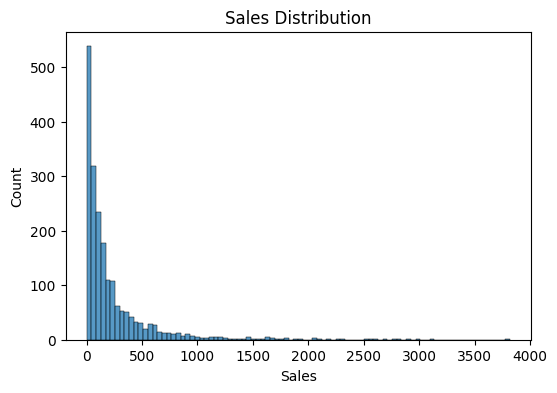

In [30]:

# Sales Distribution
plt.figure(figsize=(6,4))
sns.histplot(x=ecommerce_df['Sales'])

plt.title('Sales Distribution')
plt.xlabel('Sales')

plt.savefig('..//Plots/sales_distribution.png')
plt.show()

bar chart is effective for comparing values across discrete categories. It makes differences between categories easy to see at a glance.

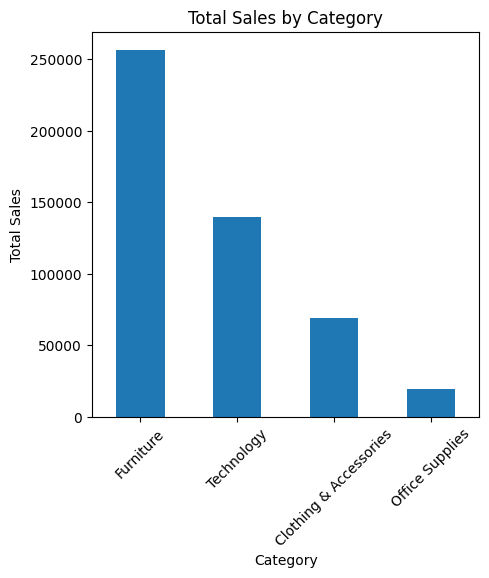

In [31]:
# Sales by Category
category_sales = ecommerce_df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(5,5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.savefig('..//Plots/sales_by_category.png')
plt.show()

A scatter plot is ideal for visualizing relationships between two numerical variables. It helps identify trends, clusters, and anomalies.

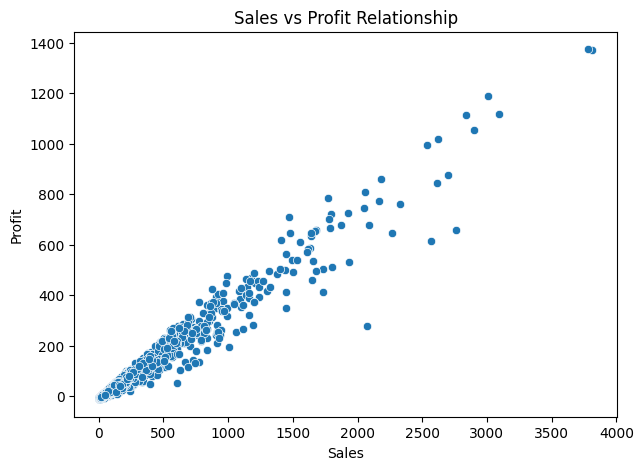

In [32]:
#sale by category 
plt.figure(figsize=(7,5))
sns.scatterplot(data=ecommerce_df, x='Sales', y='Profit')

plt.title('Sales vs Profit Relationship')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.savefig('..//Plots/sales_vs_profit.png')
plt.show()

Data Visualization

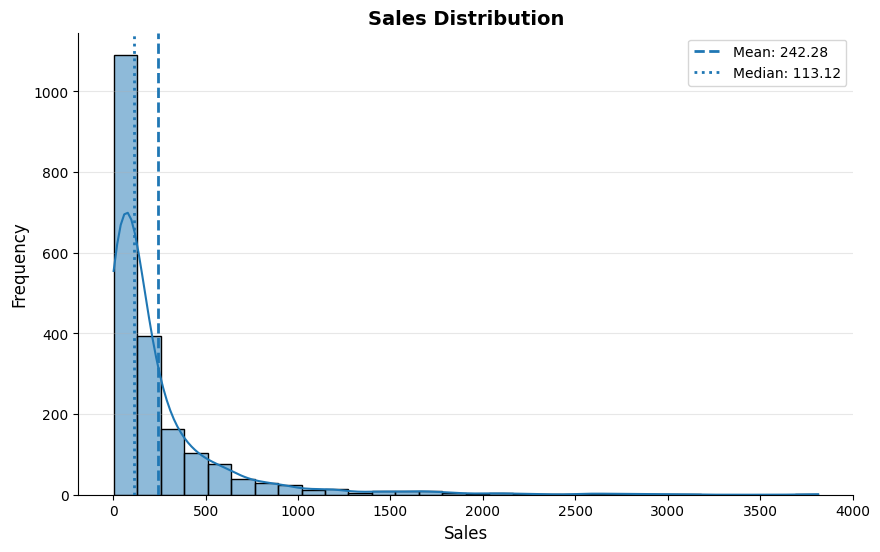

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=ecommerce_df,
    x='Sales',
    bins=30,
    kde=True
)

mean_sales = ecommerce_df['Sales'].mean()
median_sales = ecommerce_df['Sales'].median()

plt.axvline(mean_sales, linestyle='--', linewidth=2, label=f'Mean: {mean_sales:.2f}')
plt.axvline(median_sales, linestyle=':', linewidth=2, label=f'Median: {median_sales:.2f}')

plt.title('Sales Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.legend()
plt.grid(axis='y', alpha=0.3)
sns.despine()

plt.show()

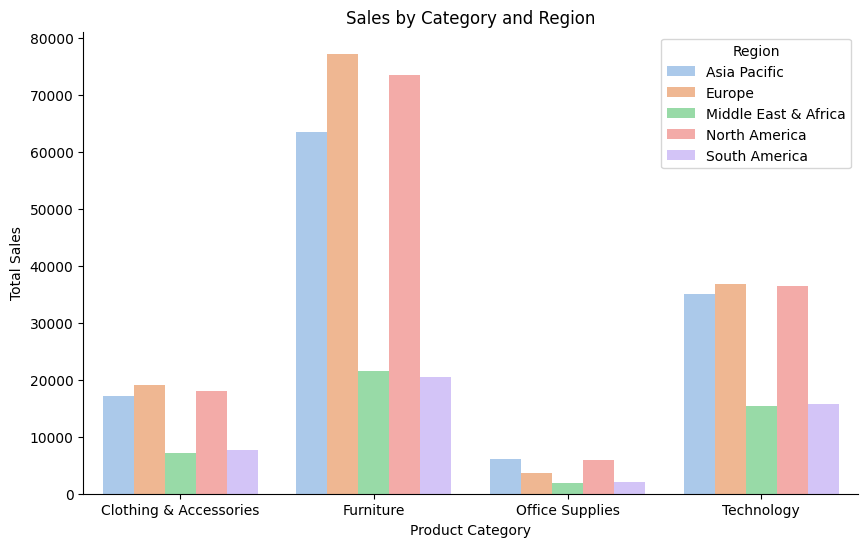

In [48]:
sales_cat_region = (
    ecommerce_df
    .groupby(['Product_Category', 'Region'])['Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sales_cat_region,
    x='Product_Category',
    y='Sales',
    hue='Region',
    palette='pastel'
)

plt.title('Sales by Category and Region')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.legend(title='Region')

sns.despine()
plt.show()

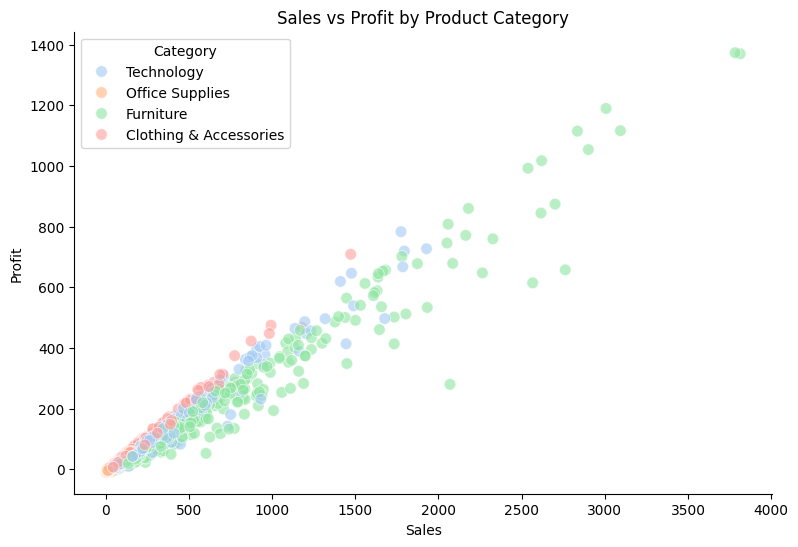

In [50]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=ecommerce_df,
    x='Sales',
    y='Profit',
    hue='Product_Category',
    alpha=0.6,
    s=70,
    palette='pastel'
)

plt.title('Sales vs Profit by Product Category')
plt.xlabel('Sales')
plt.ylabel('Profit')

sns.despine()
plt.legend(title='Category')


plt.show()

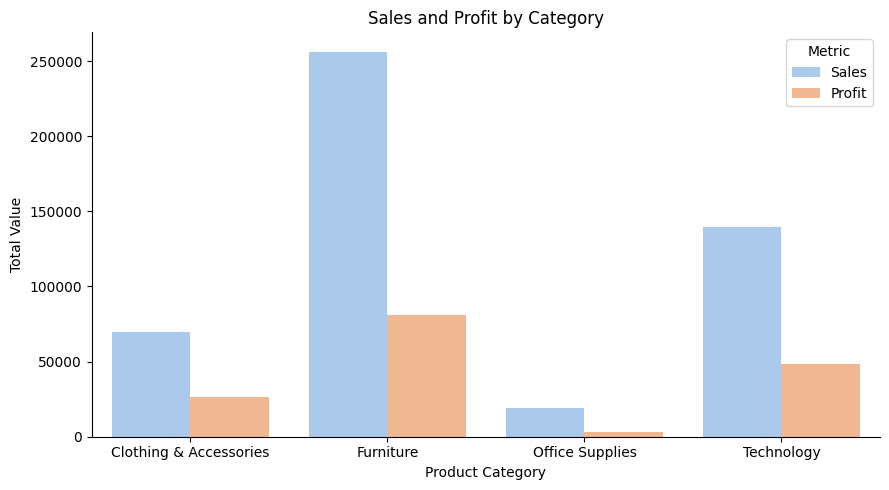

In [51]:
category_summary = (
    ecommerce_df
    .groupby("Product_Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))

category_summary_melt = category_summary.melt(
    id_vars="Product_Category",
    value_vars=["Sales", "Profit"],
    var_name="Metric",
    value_name="Value"
)

sns.barplot(
    data=category_summary_melt,
    x="Product_Category",
    y="Value",
    hue="Metric",
    palette="pastel"
)

plt.title("Sales and Profit by Category")
plt.xlabel("Product Category")
plt.ylabel("Total Value")

plt.xticks(rotation=0)
sns.despine()
plt.legend(title="Metric")

plt.tight_layout()
plt.savefig('..//Plots/sales_profit_by_category.png')
plt.show()

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import matplotlib.pyplot as plt
plt.style.use('ggplot')

if 'category_summary' not in globals():
    if 'ecommerce_df' not in globals():
        ecommerce_df = pd.read_csv('../Data/global_ecommerce_sales.csv')

    category_summary = (
        ecommerce_df
        .groupby("Product_Category")[["Sales", "Profit"]]
        .sum()
    )

category_summary.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Sales and Profit by Category')
plt.xlabel('Product Category')
plt.ylabel('Total Value')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('..//Plots/sales_profit_by_category.png')
plt.show()

category_summary.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Sales and Profit by Category')
plt.xlabel('Product Category')
plt.ylabel('Total Value')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('..//Plots/sales_profit_by_category.png')
plt.show()

NameError: name 'ecommerce_df' is not defined